In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [127]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [129]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [130]:
x = df.drop(columns=['Survived'])
y = df.Survived

In [131]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [132]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [133]:
x_train.isnull().mean() * 100

Age       20.786517
Fare       5.056180
Family     0.000000
dtype: float64

In [134]:
mean_age = x_train.Age.mean()
median_age = x_train.Age.median()

mean_fare = x_train.Fare.mean()
median_fare = x_train.Fare.median()

In [135]:
x_train['Age_median'] = x_train.Age.fillna(median_age)
x_train['Age_mean'] = x_train.Age.fillna(mean_age)

x_train['Fare_median'] = x_train.Fare.fillna(median_fare)
x_train['Fare_mean'] = x_train.Fare.fillna(mean_fare)

In [136]:
x_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
476,34.0,21.0000,1,34.00,34.000000,21.0000,21.0000
207,26.0,18.7875,0,26.00,26.000000,18.7875,18.7875
464,NaN,8.0500,0,28.75,29.785904,8.0500,8.0500
165,9.0,20.5250,2,9.00,9.000000,20.5250,20.5250
307,17.0,108.9000,1,17.00,17.000000,108.9000,108.9000


In [137]:
print('Original Age variable variance:', x_train.Age.var())
print('Age Variance after median imputaion:', x_train.Age_median.var())
print('Age Variace after mean imputation:', x_train.Age_mean.var())

print('\nOriginal Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after median imputation: ', x_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', x_train['Fare_mean'].var())

Original Age variable variance: 204.3495133904614
Age Variance after median imputaion: 161.9895663346054
Age Variace after mean imputation: 161.81262452718673

Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2340.0910219753637
Fare Variance after mean imputation:  2324.2385256705547


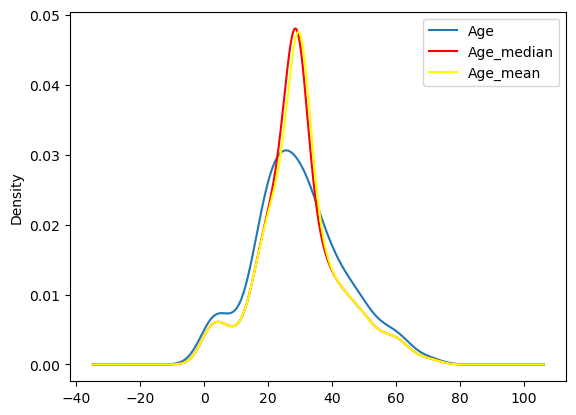

In [138]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution:
x_train.Age.plot(kind='kde',ax=ax)

# variable imputed with the median:
x_train.Age_median.plot(kind = 'kde',ax=ax, color='red')

# variable imputed with mean:
x_train.Age_mean.plot(kind='kde',ax=ax,color='yellow')

# Add legends:
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [139]:
# we can see there is huge change due to imputation using mean and median so we shouldn't use this on Age:

# we can do same for fare

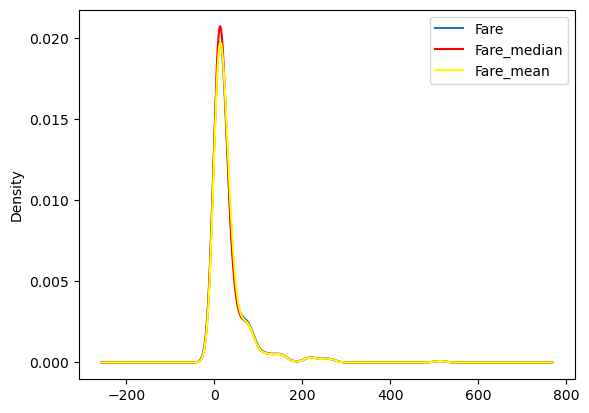

In [140]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution:
x_train.Fare.plot(kind='kde',ax=ax)

# variable imputed with the median:
x_train.Fare_median.plot(kind = 'kde',ax=ax, color='red')

# variable imputed with mean:
x_train.Fare_mean.plot(kind='kde',ax=ax,color='yellow')

# Add legends:
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

# here there isnot much change so we can use imputation for Fare:

In [141]:
x_train.cov() #covariance

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


In [142]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


<Axes: >

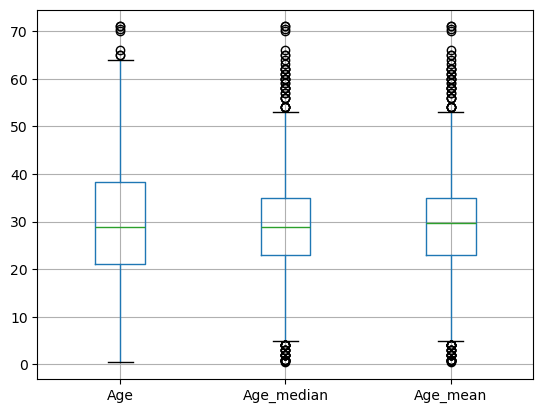

In [143]:
x_train[['Age','Age_median','Age_mean']].boxplot()

# here IQR has shrink due which the outliers are much more than before: not good for Age:

<Axes: >

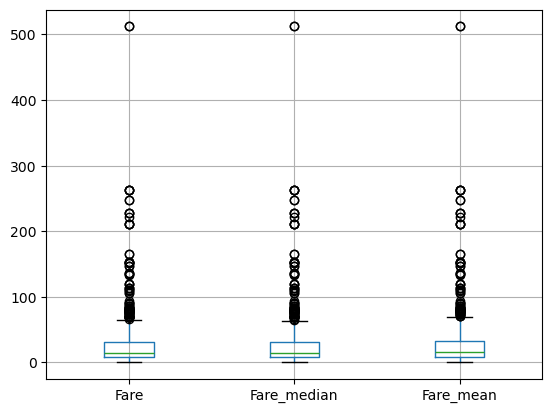

In [144]:
x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

# now we can do the same using SKlearn:

In [145]:
x_train, x_test, y_train, t_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [146]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [147]:
trf = ColumnTransformer([
    ('imputer1', imputer1,['Age']),
    ('imputer2', imputer2,['Fare'])
],remainder='passthrough', force_int_remainder_cols=False)

In [148]:
trf.fit(x_train)

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [149]:
trf.named_transformers_['imputer1'].statistics_  # meadian age

array([28.75])

In [150]:
trf.named_transformers_['imputer2'].statistics_ # mean fare

array([32.61759689])

In [151]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [152]:
x_train #scikit learn convert data into array format:

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))